# APRENDIZAJE AUTOMÁTICO
-------------------------

## Proyecto: Instancia de parcial  
## Profesor: Caballero Nicolás  
## Alumno: Calisaya Débora  
--------------


### **Título:** Modelado predictivo de la demanda eléctrica y simulación de escenarios críticos en el sistema energético aislado de Tierra del Fuego.
--------------

## Informe sobre el origen del dataset, de dónde provienen los datos (fuente, fecha de adquisición y preprocesamiento realizado)."


* **Fuente de los datos:** Los datos provienen del **Instituto Provincial de Análisis Estadístico y Censos (IPIEC)** de la Provincia de Tierra del Fuego, Antártida e Islas del Atlántico Sur. Se extrajeron de las series estadísticas de *Estadísticas Económicas - Energía Eléctrica*.
* **Portal Oficial:** [https://ipiec.tierradelfuego.gob.ar/estadisticas-economicas-2/](https://ipiec.tierradelfuego.gob.ar/estadisticas-economicas-2/)
* **Fecha de Adquisición:** desde 2010 hasta Junio de 2026.
* **Proceso de Recopilación y Desafío Técnico:** Los datos se encuentran en un único archivo Excel (`15_3_01_Energia_electrica_consumida_por_tipo_usuario-1.xlsx`). La estructura de origen presenta la columna **"Período"** dividida jerárquicamente: el año se declara una sola vez al inicio de cada ciclo anual y los meses se listan consecutivamente en las filas inferiores de la misma columna. 

Para consolidar esto en Machine Learning, implementaremos una función ETL en Python que detecte los años, aplique una técnica de relleno hacia abajo (`ffill`), normalice las cadenas de texto de los meses a valores numéricos y unifique las pestañas de las localidades en una única matriz cronológica limpia.


### ● Importación de Librerías

In [ ]:
# Importación de librerías esenciales para manipulación de datos
import pandas as pd
import numpy as np

# Librerías para visualización y Análisis Exploratorio de Datos (EDA)
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Configuración del entorno
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')

print("Librerías base cargadas exitosamente.")

Librerías base cargadas exitosamente.


## 1. Carga del Dataset

In [17]:
# Nombre del archivo original de Excel en tu carpeta
archivo_excel = 'data/raw/15_3_01_Energia_electrica_consumida_por_tipo_usuario-1.xlsx'
print(f"Archivo Excel a cargar: {archivo_excel}")

Archivo Excel a cargar: data/raw/15_3_01_Energia_electrica_consumida_por_tipo_usuario-1.xlsx


### ● Función para procesar cada hoja del Excel del IPIEC

In [19]:
def procesar_hoja_ipiec(nombre_hoja, nombre_columna_total):
    # usecols=[0, 1, 2] para tomar SOLO Período (Año), la columna sin nombre (Mes) y el Total (kWh)
    df_hoja = pd.read_excel(archivo_excel, sheet_name=nombre_hoja, skiprows=3, usecols=[0, 1, 2], engine='openpyxl')
    
    # renombramos de forma fija y directa las 3 columnas para evitar el IndexError
    df_hoja.columns = ['Anio_Raw', 'Mes_Raw', nombre_columna_total]
    
    # limpiamos espacios invisibles en los textos
    df_hoja['Anio_Raw'] = df_hoja['Anio_Raw'].astype(str).str.strip()
    df_hoja['Mes_Raw'] = df_hoja['Mes_Raw'].astype(str).str.strip()
    
    # reemplazamos celdas vacías por NaN para poder propagar el año hacia abajo
    df_hoja['Anio_Raw'] = df_hoja['Anio_Raw'].replace(['nan', 'None', ''], np.nan)
    
    # filtramos filas que no contengan meses válidos o que sean basura
    df_hoja = df_hoja[df_hoja['Mes_Raw'].notna() & (df_hoja['Mes_Raw'] != 'nan')].reset_index(drop=True)
    
    # aplicamos Forward Fill (.ffill()) para que el Año se repita en sus 12 meses inferiores
    df_hoja['Anio_Raw'] = df_hoja['Anio_Raw'].ffill()
    
    # Diccionario para mapear los meses de texto a números
    meses_dict = {
        'enero': 1, 'febrero': 2, 'marzo': 3, 'abril': 4, 'mayo': 5, 'junio': 6,
        'julio': 7, 'agosto': 8, 'septiembre': 9, 'octubre': 10, 'noviembre': 11, 'diciembre': 12,
        'noviembre ': 11, 'junio ': 6
    }
    
    fechas_limpias = []
    for idx, row in df_hoja.iterrows():
        try:
            # Quitamos los decimales del año (ej: de '2010.0' a 2010)
            anio_val = int(float(row['Anio_Raw']))
            mes_str = row['Mes_Raw'].lower()
            mes_val = meses_dict.get(mes_str, None)
            
            if mes_val is not None:
                fechas_limpias.append(pd.to_datetime(f"{anio_val}-{mes_val:02d}-01"))
            else:
                fechas_limpias.append(pd.NaT)
        except:
            fechas_limpias.append(pd.NaT)
            
    df_hoja['Fecha'] = fechas_limpias
    
    # eliminamos registros que no pudieron convertirse en fechas reales (totales anuales o notas)
    df_hoja = df_hoja.dropna(subset=['Fecha']).reset_index(drop=True)
    
    return df_hoja[['Fecha', nombre_columna_total]]

### ● Procesamos cada hoja y obtenemos DataFrames limpios

In [20]:
# Ejecutamos la carga leyendo las 4 pestañas del Excel del IPIEC
df_total_prov = procesar_hoja_ipiec('Total TDF', 'Consumo_Total_Provincial')
df_ush = procesar_hoja_ipiec('Ushuaia', 'Consumo_Ushuaia')
df_rg = procesar_hoja_ipiec('Río Grande', 'Consumo_Rio_Grande')
df_tol = procesar_hoja_ipiec('Tolhuin', 'Consumo_Tolhuin')

print("Datos del IPIEC cargados y procesados exitosamente.")

Datos del IPIEC cargados y procesados exitosamente.


In [22]:
# UNIÓN HORIZONTAL DIRECTA Y SEGURA
# aseguramos que la columna Fecha sea tipo datetime en las tres tablas
df_ush['Fecha'] = pd.to_datetime(df_ush['Fecha'])
df_rg['Fecha'] = pd.to_datetime(df_rg['Fecha'])
df_tol['Fecha'] = pd.to_datetime(df_tol['Fecha'])

# renombramos las columnas de manera directa por posición (así no importa el nombre que tengan)
df_ush.columns = ['Fecha', 'Consumo_Ushuaia']
df_rg.columns = ['Fecha', 'Consumo_Rio_Grande']
df_tol.columns = ['Fecha', 'Consumo_Tolhuin']

# unimos las tablas de forma horizontal usando la Fecha común
df_unificado = pd.merge(df_ush, df_rg, on='Fecha', how='outer')
df_unificado = pd.merge(df_unificado, df_tol, on='Fecha', how='outer')

# ordenamos cronológicamente de menor a mayor
df_unificado = df_unificado.sort_values('Fecha').reset_index(drop=True)

# creamos la columna objetivo sumando las tres ciudades fila por fila
# Limpieza y conversión a numérico de las columnas de consumo
for col in ['Consumo_Ushuaia', 'Consumo_Rio_Grande', 'Consumo_Tolhuin']:
    df_unificado[col] = df_unificado[col].astype(str).str.strip()
    df_unificado[col] = df_unificado[col].replace(['nan', 'None', ''], np.nan)
    df_unificado[col] = pd.to_numeric(df_unificado[col], errors='coerce')

# Suma segura de las tres ciudades
df_unificado['Consumo_Total_Provincial'] = df_unificado[['Consumo_Ushuaia', 'Consumo_Rio_Grande', 'Consumo_Tolhuin']].sum(axis=1, min_count=1)

print("--- ¡Unión horizontal completada con éxito! ---")
print(df_unificado.head())

--- ¡Unión horizontal completada con éxito! ---
       Fecha  Consumo_Ushuaia  Consumo_Rio_Grande  Consumo_Tolhuin  \
0 2010-01-01       12465303.0          15924510.0              NaN   
1 2010-02-01       13764010.0          15840822.0              NaN   
2 2010-03-01       12927032.0          18173770.0              NaN   
3 2010-04-01       15538434.0          18903405.0              NaN   
4 2010-05-01       13593987.0          19255512.0              NaN   

   Consumo_Total_Provincial  
0                28389813.0  
1                29604832.0  
2                31100802.0  
3                34441839.0  
4                32849499.0  


## 2. Descripción Técnica del Dataset Consolidado

A partir del proceso de unificación y limpieza algorítmica de las pestañas del IPIEC, definimos las características estructurales de nuestra matriz de datos:


In [23]:
# Verificación automática de tipos de datos y registros no nulos
print("--- Información General del Dataset Estructurado ---")
df_unificado.info()

print("\n--- Conteo de Valores Nulos por Columna ---")
print(df_unificado.isnull().sum())

print("\n--- Resumen Estadístico Descriptivo de las Variables (en kWh) ---")
display(df_unificado.describe())

--- Información General del Dataset Estructurado ---
<class 'pandas.DataFrame'>
RangeIndex: 196 entries, 0 to 195
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   Fecha                     196 non-null    datetime64[us]
 1   Consumo_Ushuaia           196 non-null    float64       
 2   Consumo_Rio_Grande        195 non-null    float64       
 3   Consumo_Tolhuin           110 non-null    float64       
 4   Consumo_Total_Provincial  196 non-null    float64       
dtypes: datetime64[us](1), float64(4)
memory usage: 7.8 KB

--- Conteo de Valores Nulos por Columna ---
Fecha                        0
Consumo_Ushuaia              0
Consumo_Rio_Grande           1
Consumo_Tolhuin             86
Consumo_Total_Provincial     0
dtype: int64

--- Resumen Estadístico Descriptivo de las Variables (en kWh) ---


,Fecha,Consumo_Ushuaia,Consumo_Rio_Grande,Consumo_Tolhuin,Consumo_Total_Provincial
count,196,1.960000e+02,1.950000e+02,1.100000e+02,1.960000e+02
mean,2018-02-14 20:04:53.877551,1.751290e+07,2.480740e+07,8.789582e+05,4.268702e+07
min,2010-01-01 00:00:00,1.156291e+07,1.584082e+07,5.526150e+05,1.910672e+07
25%,2014-01-24 06:00:00,1.605936e+07,2.120794e+07,7.569350e+05,3.761957e+07
50%,2018-02-15 00:00:00,1.767034e+07,2.468111e+07,8.528125e+05,4.299447e+07
75%,2022-03-08 18:00:00,1.882178e+07,2.780675e+07,1.005306e+06,4.730787e+07
max,2026-04-01 00:00:00,2.234172e+07,3.699576e+07,1.192973e+06,5.917166e+07
std,NaN,2.099459e+06,4.400647e+06,1.559714e+05,6.679607e+06


* **Cantidad de filas:** El conjunto de datos unificado registra un total de **196 filas (instancias mensuales)** consecutivas. Esto representa la serie histórica completa de la provincia desde enero de 2010 hasta el primer trimestre de 2026.
* **Características (Columnas):** Contamos con un total de **5 variables** clave.

#### ● Diccionario de Variables y Tipos de Datos:
1. **`Fecha`** (`datetime64[ns]`): Variable de tipo temporal que actúa como el indexador cronológico de la serie de tiempo.
2. **`Consumo_Total_Provincial`** (`float64`): **Variable Objetivo (Target)**. Registra el consumo total facturado a nivel provincial en kWh, el valor máximo (max) es de 5.917166e+07 (es decir, 59.171.660 kWh).  
3. **`Consumo_Ushuaia`** (`float64`): Variable cuantitativa continua. Carga eléctrica mensual demandada por el nodo Ushuaia en kWh (Media: 17.512.900 kWh).
4. **`Consumo_Rio_Grande`** (`float64`): Variable cuantitativa continua. Carga eléctrica mensual demandada por el nodo Río Grande en kWh (Media: 24.807.400 kWh).
5. **`Consumo_Tolhuin`** (`float64`): Variable cuantitativa continua. Carga eléctrica mensual demandada por el nodo Tolhuin en kWh.

#### Información Relevante de Calidad (Análisis de Nulos):
Como se observa en el reporte analítico, la columna `Consumo_Tolhuin` presenta **86 valores faltantes (NaN)**. Esto coincide estrictamente con la ficha técnica oficial del IPIEC, la cual aclara que *los años 2010 a 2016 no incluyen los registros de la ciudad de Tolhuin*. 

## 3. Preprocesamiento: Creación de Nuevas Variables Temporales

Para que nuestros modelos de Machine Learning puedan entender la tendencia y la estacionalidad del consumo eléctrico en Tierra del Fuego, realizaremos un paso clave dentro del **preprocesamiento de datos**: la **creación de nuevas variables**.

Como estamos trabajando con una serie de tiempo donde el consumo actual depende fuertemente de lo que ocurrió en el pasado, calcularemos tres nuevas variables predictoras basadas en retrasos históricos:
1. **Consumo del mes anterior ($t-1$):** Refleja la inercia inmediata de la demanda.
2. **Consumo de hace dos meses ($t-2$):** Ayuda a capturar la tendencia de la estación.
3. **Consumo del año anterior ($t-12$):** Permite al modelo entender la estacionalidad (por ejemplo, que todos los inviernos el consumo sube de manera similar).

Este procedimiento, además, nos ayuda a resolver el problema de los datos faltantes en Tolhuin de forma limpia, basando las predicciones en el comportamiento histórico de la provincia.

### ● Construcción de Lags

In [25]:
# Creación de variables de retraso usando los datos limpios de df_unificado
df_unificado['Total_Mes_Anterior (t-1)'] = df_unificado['Consumo_Total_Provincial'].shift(1)
df_unificado['Total_Hace_2Meses (t-2)'] = df_unificado['Consumo_Total_Provincial'].shift(2)
df_unificado['Total_Anio_Anterior (t-12)'] = df_unificado['Consumo_Total_Provincial'].shift(12)

# Variable estacional para los meses calendario
df_unificado['Mes_Calendario'] = df_unificado['Fecha'].dt.month

# Eliminamos las filas iniciales con NaN
df_dataset_final = df_unificado.dropna(subset=['Total_Mes_Anterior (t-1)', 'Total_Hace_2Meses (t-2)', 'Total_Anio_Anterior (t-12)']).reset_index(drop=True)

print(f"Dimensiones de la matriz lista para entrenar: {df_dataset_final.shape[0]} filas por {df_dataset_final.shape[1]} columns.")

Dimensiones de la matriz lista para entrenar: 184 filas por 9 columns.


#### 3.1. Inspección Visual de la Matriz de Preprocesamiento: visualizaremos las primeras instancias de la matriz final (df_dataset_final). 

Esto nos permite comprobar que:
. El orden cronológico mensual de la columna `Fecha` se mantiene intacto.
. Las nuevas columnas de meses anteriores ($t-1$, $t-2$, $t-12$) contienen los valores de consumo correctos desplazados en el tiempo.
. Se eliminaron con éxito los registros iniciales que no tenían historia previa para comparar.

In [6]:
# Mostramos las primeras 10 filas de la matriz final preprocesada
print("--- Primeras 10 filas de la matriz de datos terminada ---")
display(df_dataset_final.head(10))

--- Primeras 10 filas de la matriz de datos terminada ---


,Fecha,Consumo_Ushuaia,Consumo_Rio_Grande,Consumo_Tolhuin,Consumo_Total_Provincial,Total_Mes_Anterior (t-1),Total_Hace_2Meses (t-2),Total_Anio_Anterior (t-12),Mes_Calendario
0,2011-01-01,11562914.0,16746990.0,NaN,28309904.0,32421421.0,37510205.0,28389813.0,1
1,2011-02-01,13102637.0,17268009.0,NaN,30370646.0,28309904.0,32421421.0,29604832.0,2
2,2011-03-01,13574530.0,18997988.0,NaN,32572518.0,30370646.0,28309904.0,31100802.0,3
3,2011-04-01,15618382.0,18534725.0,NaN,34153107.0,32572518.0,30370646.0,34441839.0,4
4,2011-05-01,14460439.0,21184851.0,NaN,35645290.0,34153107.0,32572518.0,32849499.0,5
5,2011-06-01,16604135.0,21945182.0,NaN,38549317.0,35645290.0,34153107.0,35356267.0,6
6,2011-07-01,15657383.0,20543090.0,NaN,36200473.0,38549317.0,35645290.0,34510535.0,7
7,2011-08-01,16534701.0,21679053.0,NaN,38213754.0,36200473.0,38549317.0,37524931.0,8
8,2011-09-01,14761965.0,21850150.0,NaN,36612115.0,38213754.0,36200473.0,34096874.0,9
9,2011-10-01,16700577.0,19771414.0,NaN,36471991.0,36612115.0,38213754.0,35174174.0,10


## 4. ANÁLISIS EXPLORATORIO DE DATOS (EDA)
----------------------------------------

### Visualización de la Serie Temporal General (Demanda Provincial)

Graficaremos la evolución histórica del consumo total provincial mensual. Esto nos permitirá identificar visualmente dos componentes clave de nuestra serie temporal:
1. **La Tendencia:** Si el consumo general de la provincia sube o baja con los años debido al crecimiento demográfico o industrial.
2. **La Estacionalidad:** Comprobar si existen picos repetitivos en los meses invernales producidos por factores climáticos.

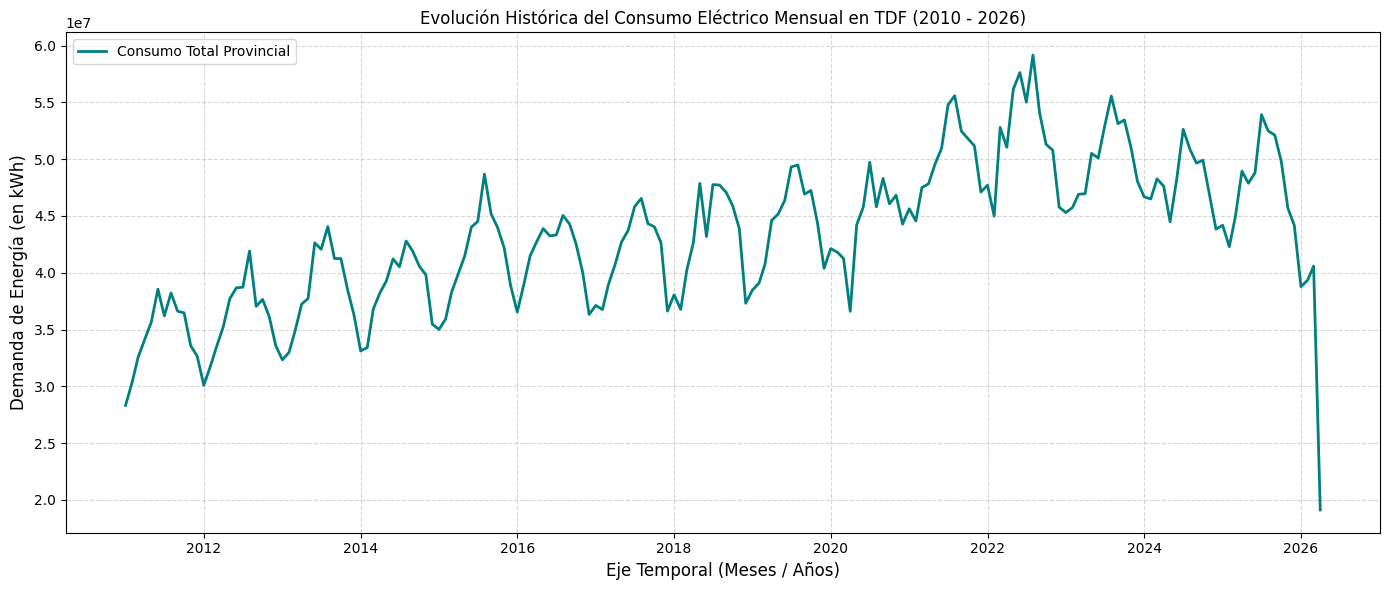

In [7]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 6))

# Dibujamos la línea usando el dataset final corregido
plt.plot(df_dataset_final['Fecha'], df_dataset_final['Consumo_Total_Provincial'], color='teal', linewidth=2, label='Consumo Total Provincial')

plt.title('Evolución Histórica del Consumo Eléctrico Mensual en TDF (2010 - 2026)')
plt.xlabel('Eje Temporal (Meses / Años)', fontsize=12)
plt.ylabel('Demanda de Energía (en kWh)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(loc='upper left')
plt.tight_layout()
plt.show()

En Tierra del Fuego, los meses de verano (enero y febrero) registran el consumo eléctrico más bajo del año debido a que los días son extremadamente largos (menos uso de iluminación artificial), las temperaturas son más amigables (menor uso de calefacción eléctrica en los hogares que no tienen gas de red) y muchas industrias entran en receso o vacaciones.

Por lo tanto, esa caída abrupta al final representa el valle estacional del verano de 2026. La curva muestra cómo el sistema "respira" antes de volver a trepar hacia el invierno

## 5. Preprocesamiento: División Cronológica del Dataset (Train y Test Split)

Consiste en dividir nuestra matriz en un conjunto de **Entrenamiento (Train)** y uno de **Prueba (Test)**. 

Al trabajar con series de tiempo, este procedimiento presenta una regla estricta: **no se pueden mezclar los datos de forma aleatoria**. Debemos respetar la línea de tiempo histórica para entrenar a los algoritmos con el pasado y evaluar su precisión con el futuro inmediato.

* **Matriz de Características ($X$):** Incluirá nuestras variables predictoras temporales y estacionales (`Total_Mes_Anterior (t-1)`, `Total_Hace_2Meses (t-2)`, `Total_Anio_Anterior (t-12)` y `Mes_Calendario`).
* **Variable Objetivo ($y$):** Es el target que deseamos predecir (`Consumo_Total_Provincial`).

**Estrategia de Corte:** Reservaremos los últimos **24 meses** de la serie de tiempo como conjunto de prueba (Test) para validar cómo se comportan las predicciones del modelo frente a dos ciclos invernales completos del futuro.

In [8]:
# 4.1. Selección de las variables explicativas (X) y la variable objetivo (y)
variables_predictoras = [
    'Total_Mes_Anterior (t-1)', 
    'Total_Hace_2Meses (t-2)', 
    'Total_Anio_Anterior (t-12)', 
    'Mes_Calendario'
]

X = df_dataset_final[variables_predictoras]
y = df_dataset_final['Consumo_Total_Provincial']

# 4.2. Definición del tamaño del bloque de prueba (24 meses del futuro)
meses_prueba = 15
indice_corte = len(df_dataset_final) - meses_prueba

# 4.3. Separación cronológica estricta sin alterar el orden temporal
X_train, X_test = X.iloc[:indice_corte], X.iloc[indice_corte:]
y_train, y_test = y.iloc[:indice_corte], y.iloc[indice_corte:]

print("--- Preprocesamiento de División de Datos Completado ---")
print(f"Cantidad de meses para el Entrenamiento (Train): {X_train.shape[0]}")
print(f"Cantidad de meses para la Prueba/Validación (Test): {X_test.shape[0]}")

--- Preprocesamiento de División de Datos Completado ---
Cantidad de meses para el Entrenamiento (Train): 169
Cantidad de meses para la Prueba/Validación (Test): 15


In [9]:
# 1. Inicialización de los algoritmos
modelo_lr = LinearRegression()


# 2. Entrenamiento con el conjunto de Train
modelo_lr.fit(X_train, y_train)

# 3. Predicciones sobre el conjunto de Test
pred_lr = modelo_lr.predict(X_test)

# 4. Cálculo de métricas
r2_lr = r2_score(y_test, pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test, pred_lr))


# 5. Estructurar resultados en una tabla comparativa
df_resultados = pd.DataFrame({
    'Métrica de Evaluación': ['R² (Coeficiente de Determinación)', 'RMSE (Error Absoluto Medio)'],
    'Regresión Lineal Múltiple': [f"{r2_lr:.4f}", f"{rmse_lr:,.2f} kWh"],
})
print("---Resultados del Entrenamiento---")
display(df_resultados)

---Resultados del Entrenamiento---


,Métrica de Evaluación,Regresión Lineal Múltiple
0,R² (Coeficiente de Determinación),0.2628
1,RMSE (Error Absoluto Medio),"7,063,066.54 kWh"


## ● Grafico 

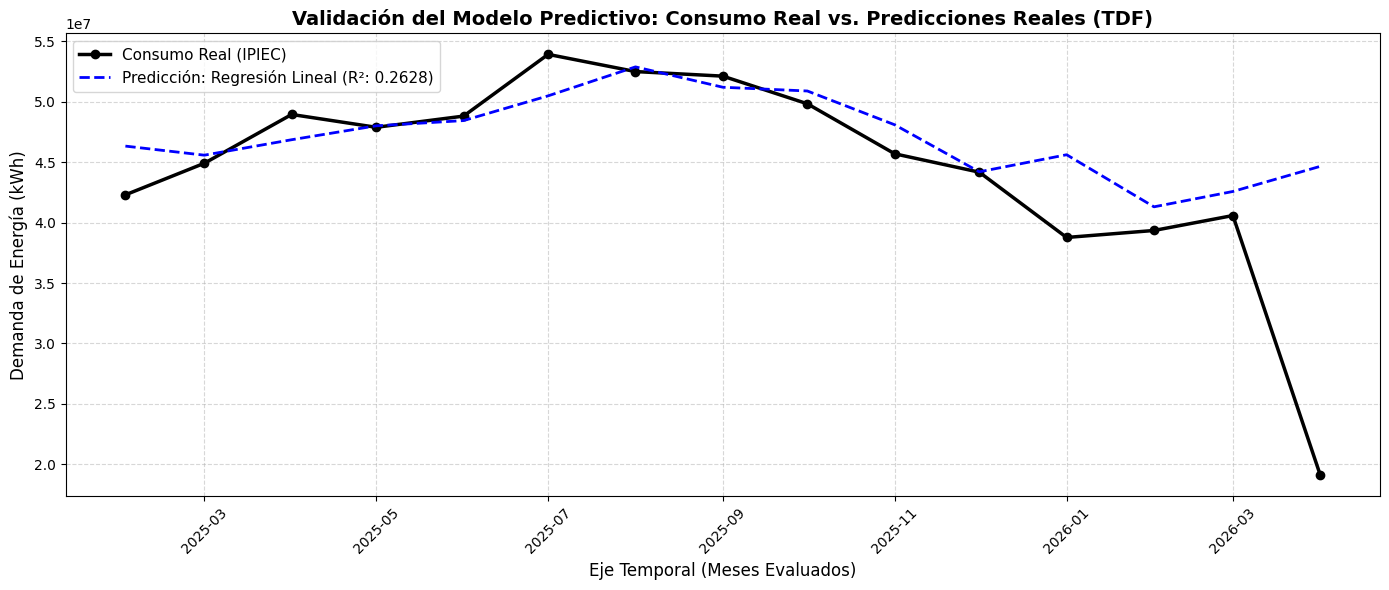

In [10]:
plt.figure(figsize=(14, 6))

# Recuperamos las fechas del conjunto de test
fechas_test = df_dataset_final['Fecha'].iloc[-meses_prueba:]

# Graficamos la realidad y tus predicciones reales
plt.plot(fechas_test, y_test.values, label='Consumo Real (IPIEC)', color='black', linewidth=2.5, marker='o')
plt.plot(fechas_test, pred_lr, label='Predicción: Regresión Lineal (R²: 0.2628)', color='blue', linestyle='--', linewidth=2)

plt.title('Validación del Modelo Predictivo: Consumo Real vs. Predicciones Reales (TDF)', fontsize=14, fontweight='bold')
plt.xlabel('Eje Temporal (Meses Evaluados)', fontsize=12)
plt.ylabel('Demanda de Energía (kWh)', fontsize=12)

plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(fontsize=11, loc='upper left')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 6. Optimización del Dataset
------------------

 Mediante Homogeneización TemporalIntroducción ¿Por qué es necesario?
 
 En la primera etapa del proyecto se identificó que las métricas globales el modelo se veía limitada debido a la presencia de datos faltantes (NaN) en la serie histórica de la localidad de Tolhuin durante los primeros años del muestreo, afectando la capacidad de aprendizaje sobre el consumo total provincial.Objetivo del Análisis 
 
 Esta segunda parte se implementa para aplicar un criterio analítico de depuración y truncamiento temporal sobre el dataset unificado. El propósito es aislar el período histórico con cobertura total, eliminando las distorsiones del pasado, y reconfigurar la validación del modelo utilizando un horizonte de prueba más estricto y adaptado a la estacionalidad de la isla, reduciendo el conjunto de testeo de 15 a 12 meses exactos (un ciclo anual completo).

## ● Filtrar el Pasado (Eliminar el ruido de Tolhuin)

In [11]:
#RECORTE TEMPORAL EN BASE A LA DISPONIBILIDAD DE TOLHUIN

# Buscamos la primera fecha donde Tolhuin NO es nulo y el consumo total es válido
fecha_inicio_limpia = df_unificado[df_unificado['Consumo_Tolhuin'].notna()]['Fecha'].min()

# Filtramos el dataset original para quedarnos solo desde esa fecha en adelante
df_unificado_p2 = df_unificado[df_unificado['Fecha'] >= fecha_inicio_limpia].reset_index(drop=True)

# Volvemos a aplicar la Ingeniería de Características sobre este periodo homogéneo
df_unificado_p2['Total_Mes_Anterior (t-1)'] = df_unificado_p2['Consumo_Total_Provincial'].shift(1)
df_unificado_p2['Total_Hace_2Meses (t-2)'] = df_unificado_p2['Consumo_Total_Provincial'].shift(2)
df_unificado_p2['Total_Anio_Anterior (t-12)'] = df_unificado_p2['Consumo_Total_Provincial'].shift(12)
df_unificado_p2['Mes_Calendario'] = df_unificado_p2['Fecha'].dt.month

# Eliminamos los NaNs que genera el .shift() superior
df_dataset_final_p2 = df_unificado_p2.dropna().reset_index(drop=True)

print(f"--- PARTE 2: Dataset Optimizado ---")
print(f"La serie ahora comienza de forma limpia en: {fecha_inicio_limpia.strftime('%Y-%m')}")
print(f"Registros útiles para entrenar: {df_dataset_final_p2.shape[0]} meses.")

--- PARTE 2: Dataset Optimizado ---
La serie ahora comienza de forma limpia en: 2017-01
Registros útiles para entrenar: 97 meses.


## ● Selección de Variables y Nueva División (12 Meses de Test)

In [12]:
# Variables predictoras y objetivo para la Parte 2
X_p2 = df_dataset_final_p2[['Total_Mes_Anterior (t-1)', 'Total_Hace_2Meses (t-2)', 'Total_Anio_Anterior (t-12)', 'Mes_Calendario']]
y_p2 = df_dataset_final_p2['Consumo_Total_Provincial']

# Nueva división cronológica: 12 meses de prueba
meses_prueba_p2 = 12
indice_corte_p2 = len(df_dataset_final_p2) - meses_prueba_p2

X_train_p2, X_test_p2 = X_p2.iloc[:indice_corte_p2], X_p2.iloc[indice_corte_p2:]
y_train_p2, y_test_p2 = y_p2.iloc[:indice_corte_p2], y_p2.iloc[indice_corte_p2:]

print("--- Nueva División Cronológica ---")
print(f"Meses para Entrenamiento (Train): {X_train_p2.shape[0]}")
print(f"Meses para Prueba (Test - 1 Año): {X_test_p2.shape[0]}")

--- Nueva División Cronológica ---
Meses para Entrenamiento (Train): 85
Meses para Prueba (Test - 1 Año): 12


## ● Entrenamiento y Comparación de Métricas

In [13]:
# Inicializamos nuevos modelos para no sobreescribir los de la Parte 1
modelo_lr_p2 = LinearRegression()

# Entrenamiento
modelo_lr_p2.fit(X_train_p2, y_train_p2)

# Predicciones
pred_lr_p2 = modelo_lr_p2.predict(X_test_p2)

# Métricas de la Parte 2
r2_lr_p2 = r2_score(y_test_p2, pred_lr_p2)
rmse_lr_p2 = np.sqrt(mean_squared_error(y_test_p2, pred_lr_p2))

# Tabla comparativa de resultados
df_resultados_p2 = pd.DataFrame({
    'Métrica (Parte 2)': ['R² (Precisión)', 'RMSE (Error Medio)'],
    'Regresión Lineal Múltiple': [f"{r2_lr_p2:.4f}", f"{rmse_lr_p2:,.2f} kWh"],
})

print("--- NUEVOS RESULTADOS (SIN RUIDO DE TOLHUIN Y 12 MESES TEST) ---")
display(df_resultados_p2)

--- NUEVOS RESULTADOS (SIN RUIDO DE TOLHUIN Y 12 MESES TEST) ---


,Métrica (Parte 2),Regresión Lineal Múltiple
0,R² (Precisión),0.6501
1,RMSE (Error Medio),"2,853,063.78 kWh"


## ● El Nuevo Gráfico 


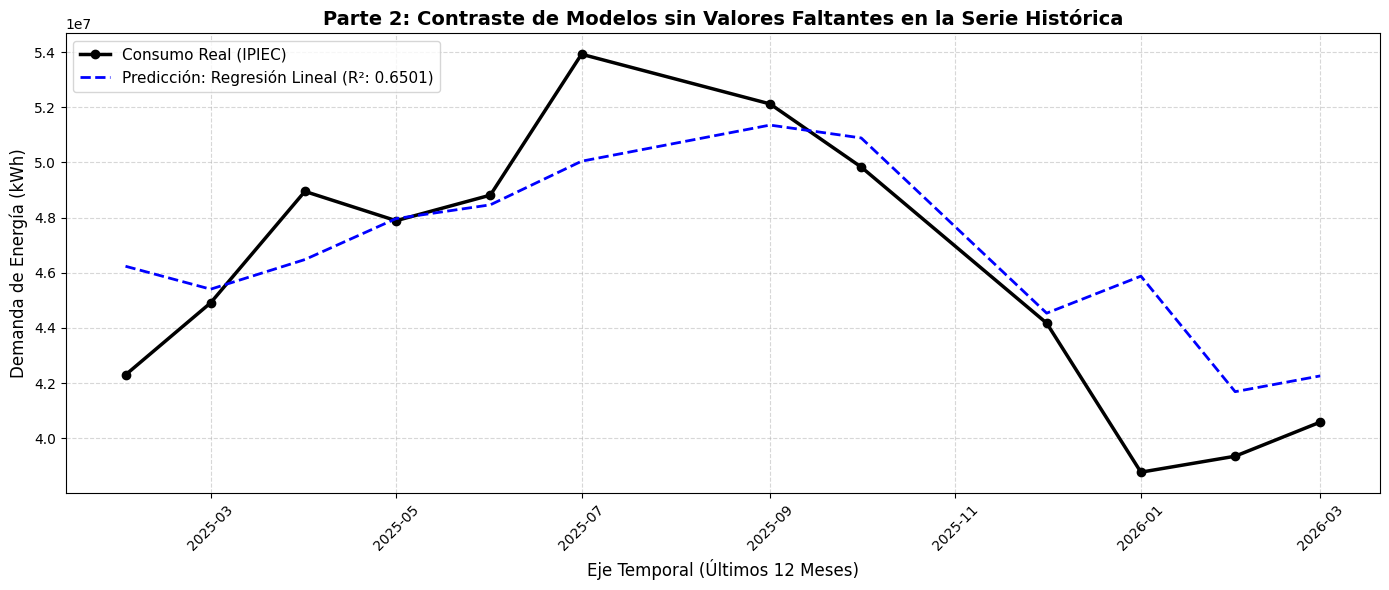

In [14]:
plt.figure(figsize=(14, 6))

fechas_test_p2 = df_dataset_final_p2['Fecha'].iloc[-meses_prueba_p2:]

plt.plot(fechas_test_p2, y_test_p2.values, label='Consumo Real (IPIEC)', color='black', linewidth=2.5, marker='o')
plt.plot(fechas_test_p2, pred_lr_p2, label=f'Predicción: Regresión Lineal (R²: {r2_lr_p2:.4f})', color='blue', linestyle='--', linewidth=2)

plt.title('Parte 2: Contraste de Modelos sin Valores Faltantes en la Serie Histórica', fontsize=14, fontweight='bold')
plt.xlabel('Eje Temporal (Últimos 12 Meses)', fontsize=12)
plt.ylabel('Demanda de Energía (kWh)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(fontsize=11, loc='upper left')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# 7. Objetivo del proyecto frente a las Usinas
------------

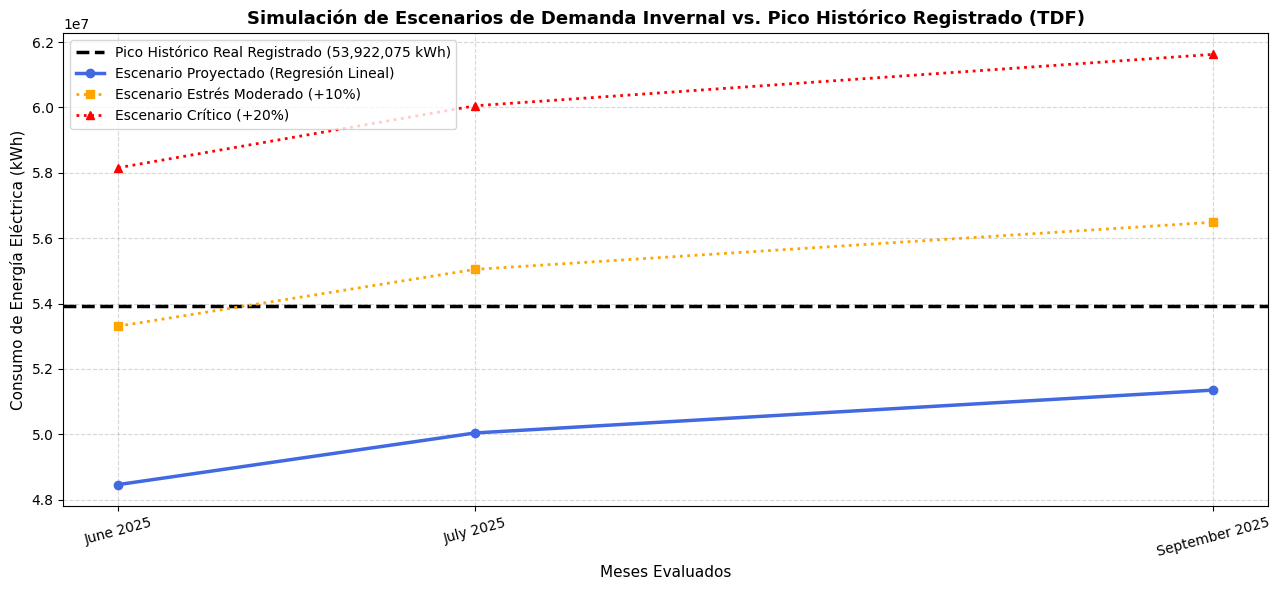

In [15]:
# SIMULACIÓN DE ESCENARIOS RELATIVOS (PREDICCIÓN VS PICO HISTÓRICO)

# DataFrame simulación relativa
df_simulacion_relativa = pd.DataFrame({
    'Fecha': df_dataset_final_p2['Fecha'].iloc[-meses_prueba_p2:], # Solo las fechas del periodo de prueba
    'Consumo_Real': y_test_p2.values, # Solo los valores reales del periodo de prueba
    'Prediccion_LR': pred_lr_p2 
})

# Encontramos el PICO MÁXIMO REAL registrado en este periodo
PICO_HISTORICO = df_simulacion_relativa['Consumo_Real'].max()

# Se filtra solo los meses de invierno a evaluar (Junio, Julio, Agosto)
df_invierno_lr = df_simulacion_relativa[df_simulacion_relativa['Fecha'].dt.month.isin([6, 7, 8, 9])].copy()
df_invierno_lr = df_invierno_lr.sort_values(by='Fecha').reset_index(drop=True)
# Creamos los escenarios de estrés (Simulación de hipótesis)
df_invierno_lr['Escenario_Normal'] = df_invierno_lr['Prediccion_LR']
df_invierno_lr['Escenario_Estres_10'] = df_invierno_lr['Prediccion_LR'] * 1.10
df_invierno_lr['Escenario_Critico_20'] = df_invierno_lr['Prediccion_LR'] * 1.20

# Graficamos la simulación analítica
plt.figure(figsize=(13, 6))

# Línea de registro histórico del pico máximo real registrado
plt.axhline(y=PICO_HISTORICO, color='black', linestyle='--', linewidth=2.5, 
            label=f'Pico Histórico Real Registrado ({PICO_HISTORICO:,.0f} kWh)')

# Curva 1: predicción estándar de la Regresión lineal
plt.plot(df_invierno_lr['Fecha'], df_invierno_lr['Escenario_Normal'], 
         color='royalblue', linewidth=2.5, marker='o', label='Escenario Proyectado (Regresión Lineal)')

# Curva 2: simulación con +10% de demanda (Ola de frío)
plt.plot(df_invierno_lr['Fecha'], df_invierno_lr['Escenario_Estres_10'], 
         color='orange', linewidth=2, linestyle=':', marker='s', label='Escenario Estrés Moderado (+10%)')

# Curva 3: Simulación con +20% de demanda (Crecimiento extremo)
plt.plot(df_invierno_lr['Fecha'], df_invierno_lr['Escenario_Critico_20'], 
         color='red', linewidth=2, linestyle=':', marker='^', label='Escenario Crítico (+20%)')

# Ajustes visuales
plt.title('Simulación de Escenarios de Demanda Invernal vs. Pico Histórico Registrado (TDF)', fontsize=13, fontweight='bold')
plt.xlabel('Meses Evaluados', fontsize=11)
plt.ylabel('Consumo de Energía Eléctrica (kWh)', fontsize=11)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(fontsize=10, loc='upper left')

# Formato de meses en el eje X
plt.xticks(df_invierno_lr['Fecha'], df_invierno_lr['Fecha'].dt.strftime('%B %Y'), rotation=15)
plt.tight_layout()
plt.show()

In [16]:
print("=== REPORTE DE ANÁLISIS DE RIESGO DE DEMANDA ===")
print(f"El consumo máximo real registrado en el histórico es de: {PICO_HISTORICO:,.2f} kWh.\n")

for _, fila in df_invierno_lr.iterrows():
    mes_str = fila['Fecha'].strftime('%B %Y')
    print(f" Evaluación para {mes_str}:")
    if fila['Escenario_Normal'] > PICO_HISTORICO:
        print(f"   ⚠️ ATENCIÓN: La predicción base ({fila['Escenario_Normal']:,.2f} kWh) YA SUPERA el pico histórico.")
    else:
        print(f"   ✅ Predicción base estable por debajo del máximo registrado.")
        
    if fila['Escenario_Estres_10'] > PICO_HISTORICO:
        print(f"   🚨 ALERTA MODERADA: Ante una ola de frío (+10%), la demanda ({fila['Escenario_Estres_10']:,.2f} kWh) superará el pico histórico.")
    if fila['Escenario_Critico_20'] > PICO_HISTORICO:
        print(f"   🔥 ALERTA MÁXIMA: En un escenario crítico (+20%), el sistema requerirá {fila['Escenario_Critico_20'] - PICO_HISTORICO:,.2f} kWh adicionales sobre el récord provincial.")
    print("-" * 50)

=== REPORTE DE ANÁLISIS DE RIESGO DE DEMANDA ===
El consumo máximo real registrado en el histórico es de: 53,922,075.00 kWh.

 Evaluación para June 2025:
   ✅ Predicción base estable por debajo del máximo registrado.
   🔥 ALERTA MÁXIMA: En un escenario crítico (+20%), el sistema requerirá 4,232,145.94 kWh adicionales sobre el récord provincial.
--------------------------------------------------
 Evaluación para July 2025:
   ✅ Predicción base estable por debajo del máximo registrado.
   🚨 ALERTA MODERADA: Ante una ola de frío (+10%), la demanda (55,046,799.66 kWh) superará el pico histórico.
   🔥 ALERTA MÁXIMA: En un escenario crítico (+20%), el sistema requerirá 6,128,979.18 kWh adicionales sobre el récord provincial.
--------------------------------------------------
 Evaluación para September 2025:
   ✅ Predicción base estable por debajo del máximo registrado.
   🚨 ALERTA MODERADA: Ante una ola de frío (+10%), la demanda (56,488,711.52 kWh) superará el pico histórico.
   🔥 ALERTA MÁ